# Information Visualization I 
## School of Information, University of Michigan

## Week 3: 
- Perception / Cognition

## Assignment Overview
### This assignment's objectives include:

- Review, refect, and apply the concepts of the perception pipeline. Justify how different encodings impact the effectiveness of a visualization depending on the human perception process.

!["Drawing"](/voc/data/preattentive_resized.png)

<p style="text-align: center;"> Preattentive Processing </p>

- Recreate visualizations and propose new and alternative visualizations using [Altair](https://altair-viz.github.io/) 

### The total score of this assignment will be 100 points consisting of:
- Case study reflection: America's Favorite 'Star Wars' Movies (And Least Favorite Characters) (25 points)
- Altair programming exercise (75 points)

### Resources:
- Article by [FiveThirtyEight](https://fivethirtyeight.com) available  [online](https://fivethirtyeight.com/features/americas-favorite-star-wars-movies-and-least-favorite-characters/) (Hickey, 2014)  
- Datasets from FiveThirtyEight, we have downloaded a subset of this data in the folder [./assets](assets)
    - The original dataset can be found at [FiveThirtyEight Star Wars Survey](https://github.com/fivethirtyeight/data/tree/master/star-wars-survey)
    

### Important notes:
1) There will be a couple of places where the numbers you get when you select rows may be a little different than 538, but the percents should still work (e.g., 828 instead of 834). You'll see this in our examples. If you can somehow get the data to match exactly, that's great too.

2) A lot of this assignment will be based on building "compound" charts. Using the wrong strategy will mean that you are spending a lot of time "cleaning up" charts. We strongly suggest reading through (and understanding) the Altair documentation [on this](https://altair-viz.github.io/user_guide/compound_charts.html).

3) Grading for this assignment is entirely done by a human grader. They will be running tests on the functions we ask you to create. This means there is no autograding (submitting through the autograder will result in an error). You are expected to test and validate your own code. 

4) Keep your notebooks clean and readable. If your code is highly messy or inefficient you will get a deduction.

5) Follow the instructions for submission on Coursera. You will be providing us a generated link to a read-only version of your notebook and a PDF. When turning in your PDF, please use the File -> Print -> Save as PDF option ***from your browser***. Do ***not*** use the File->Download as->PDF option. Complete instructions for this are under Resources in the Coursera page for this class. If you're having trouble with printing, take a look at [this video](https://youtu.be/PiO-K7AoWjk).

## Part 1. Perception and Cognition (25 points)
Read the article ["America’s Favorite ‘Star Wars’ Movies (And Least Favorite Characters),"](https://fivethirtyeight.com/features/americas-favorite-star-wars-movies-and-least-favorite-characters/) and answer the following questions:


### 1.1 List the different data types in the following visualizations and their encodings (10 points)
Look at the following visualizations. For each, list the variable, their type, and the encoding used. 

!["How rate visualization"](/voc/data/how_rate_resized.png)
!["Have seen visualization"](/voc/data/have_seen_resized.png)

Use the following table for each variable (indicate which vis each came from):
* variable name, variable type (e.g., ordinal, nominal, etc.), variable encoding (e.g., color, x-position, etc.)

For example, if you [look at this visualization](https://altair-viz.github.io/gallery/scatter_tooltips.html) one row in our table below would be: Horsepower, quantitative, x-position.

_1.1 Answer_

*Use as many rows as you need*

How People Rate the 'Star Wars' Movies

| Variable name| Variable Type (Ordinal/Nominal/Quantitative) | Variable encoding (color, x-position, etc.) |
| --- | --- | --- |
|  Star Wars Episode | Nominal | y-position |
|  ratio of (ranking_number_count/seen_all_6_films_count) | Quantitative | x-position |
|  Ranking Third | Nominal | base position (left / middle / right for rank = 1 or 2 / 3 or 4 / 5 or 6) |


Which 'Star Wars' Movies Have You Seen?

| Variable name| Variable Type (Ordinal/Nominal/Quantitative) | Variable encoding (color, x-position, etc.) |
| --- | --- | --- |
|  Star Wars Episode | Nominal | y-position |
|  ratio of (seen_Episode_count/seen_any_film_count) | Quantitative | x-position |




### 1.2 A Pie Chart Version (15 points)


!["Drawing"](/voc/data/have_seen_resized.png)

Your colleague is arguing that the chart above could be made more *effective* by using one or more pie charts. In what situations are they right? In what situations would they be wrong? If it helps makes your case, feel free to create a picture (hand drawn is fine) and load it into the notebook.

A group of pie charts could be effective (potentially as effective or more than the bar chart) if presented as shown in the mock-up below. In this approach, the quantitative variable of percentage is encoded with theta(angle) and the nominal variable (Seen/Not seen) is encoded with easily named, fully saturated colour. The number of colours used in the entire concatenation (two) means that the colour boundaries are easily distinguishable and the simplicity of the data (only two categories) means that the perceptability of the size difference between the two categories is acceptable. 

On the other hand, a single pie chart representation would not be able to effectively convey the message being conveyed by the bar chart, since the percentages being communicated to the reader are ratios calculated for each categorical variable vs a similar basis(denominator). This means that they do not add up to '1'(100%). The single pie chart would therefore be ineffective in facilitating this representation as it is best perceived as representing constituent parts of a whole. 

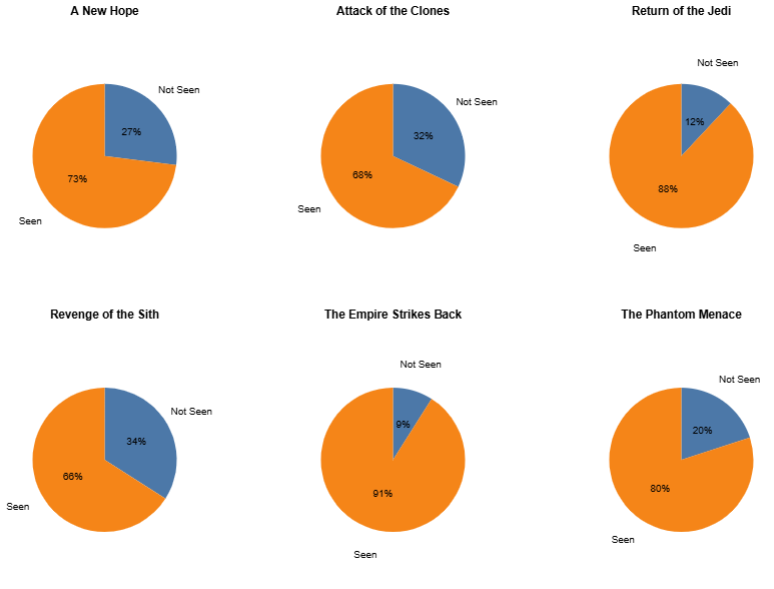


#### CODE USED TO GENERATE MOCK-UP VISUALISATION ABOVE ####
import pandas as pd
import altair as alt
df = pd.read_csv('which_movie.csv', encoding='UTF-8')
df = pd.pivot_table(df,values=['Seen','Not Seen'],
                       columns=['Episode'])
#print(df)

df_1 = df.copy().unstack().reset_index()
df_1['Percentage'] = df_1[0]
df_1['Status'] = df_1['level_1']
df_1.drop(['level_1',0],axis=1,inplace=True)
#print(df_1)

pie_base = alt.Chart(df_1).mark_arc(outerRadius=80).encode(
    theta=alt.Theta('Percentage:Q', stack=True),
    color=alt.Color('Status:N', legend=None),
    tooltip=['Episode:N', 'Status:N', 'Percentage:Q']
)

text_1 = pie_base.mark_text(radius=40).encode(
    text=alt.Text('Percentage:Q',format='.0%'),
    color=alt.Color(value='Black')
)
text_2 = pie_base.mark_text(radius=110).encode(
    text=alt.Text('Status:N'),
    color=alt.Color(value='Black')
)

labelled_pie_base = alt.layer(pie_base,text_1,text_2)    
    
pie_1 = labelled_pie_base.transform_filter(alt.datum.Episode == 'A New Hope').properties(title='A New Hope')
pie_2 = labelled_pie_base.transform_filter(alt.datum.Episode == 'Attack of the Clones').properties(title='Attack of the Clones')
pie_3 = labelled_pie_base.transform_filter(alt.datum.Episode == 'Return of the Jedi').properties(title='Return of the Jedi')
pie_4 = labelled_pie_base.transform_filter(alt.datum.Episode == 'Revenge of the Sith').properties(title='Revenge of the Sith')
pie_5 = labelled_pie_base.transform_filter(alt.datum.Episode == 'The Empire Strikes Back').properties(title='The Empire Strikes Back')
pie_6 = labelled_pie_base.transform_filter(alt.datum.Episode == 'The Phantom Menace').properties(title='The Phantom Menace')

alt.vconcat(alt.hconcat(pie_1,pie_2,pie_3), alt.hconcat(pie_4,pie_5,pie_6))


## Part 2. Altair programming exercise (75 points)
We have provided you with some code and parts of the article [America’s Favorite ‘Star Wars’ Movies (And Least Favorite Characters)](https://fivethirtyeight.com/features/americas-favorite-star-wars-movies-and-least-favorite-characters/). This article is based on the dataset:

1. [StarWars](data/StarWars.csv) Created by FiveThirtyEight based on a survey ran through SurveyMonkey Audience, surveying 1,186 respondents from June 3 to 6 2014. Available [online] (https://github.com/fivethirtyeight/data/tree/master/star-wars-survey)

To earn points for this assignment, you must:

- Recreate the visualizations in the article (replace the images in the article with a code cell that creates a visualization). We provide one example. Each visualization is worth 10 points (40 points/ 10 each x 4 total ).

    - _Partial credit can be granted for each visualization (up to 5 points) if you provide the grammar of graphics description of the visualization without a functional Altair implementation_


- Propose two variants (a "good one" and a "bad one") for a new visualization for the article. You'll be asked to justify why one is better than the other. We are specifically interested in your explanation of why the "good one" is more *effective* based on principles of perception/cognition. (35 points/ 20 points for the plots + 15 for justification)




In [1]:
import pandas as pd
import altair as alt
import numpy as np
import math
from mads.lib.path import assets
pd.options.display.max_columns = None

In [2]:
# enable correct rendering
alt.renderers.enable('mimetype')

RendererRegistry.enable('mimetype')

In [3]:
# uses intermediate json files to speed things up
alt.data_transformers.enable('json')

DataTransformerRegistry.enable('json')

In [4]:
def loadStarwarsData(filename='StarWars.csv'):
    
    # input: filename to original dataset (default StarWars.csv)
    # output: cleaned up dataframe with columns appropriately renamed
    
    filename = assets.find(filename)
    sw = pd.read_csv(filename, encoding='latin1')

    # Some format is needed for the survey dataframe, we provide the formatted dataset in a dataframe 
    sw = sw.rename(columns={'Have you seen any of the 6 films in the Star Wars franchise?':'seen_any_movie',
                            'Do you consider yourself to be a fan of the Star Wars film franchise?': 'fan',
                            'Which of the following Star Wars films have you seen? Please select all that apply.' : 'seen_EI',
                            'Unnamed: 4' : 'seen_EII',
                            'Unnamed: 5' : 'seen_EIII',
                            'Unnamed: 6' : 'seen_EIV',
                            'Unnamed: 7' : 'seen_EV',
                            'Unnamed: 8' : 'seen_EVI',
                            'Please rank the Star Wars films in order of preference with 1 being your favorite film in the franchise and 6 being your least favorite film.' : 'rank_EI',
                            'Unnamed: 10' : 'rank_EII',
                            'Unnamed: 11' : 'rank_EIII',
                            'Unnamed: 12' : 'rank_EIV',
                            'Unnamed: 13' : 'rank_EV',
                            'Unnamed: 14' : 'rank_EVI',
                            'Please state whether you view the following characters favorably, unfavorably, or are unfamiliar with him/her.' : 'Han Solo',
                            'Unnamed: 16' : 'Luke Skywalker',
                            'Unnamed: 17' : 'Princess Leia Organa',
                            'Unnamed: 18' : 'Anakin Skywalker',
                            'Unnamed: 19' : 'Obi Wan Kenobi',
                            'Unnamed: 20' : 'Emperor Palpatine',
                            'Unnamed: 21' : 'Darth Vader',
                            'Unnamed: 22' : 'Lando Calrissian',
                            'Unnamed: 23' : 'Boba Fett',
                            'Unnamed: 24' : 'C-3P0',
                            'Unnamed: 25' : 'R2 D2',
                            'Unnamed: 26' : 'Jar Jar Binks',
                            'Unnamed: 27' : 'Padme Amidala',
                            'Unnamed: 28' : 'Yoda',
                           })
    sw = sw.drop([0])
    return(sw)

sw = loadStarwarsData()

In [5]:
# take a peak to look at the data
sw.sample(5)

,RespondentID,seen_any_movie,fan,seen_EI,seen_EII,seen_EIII,seen_EIV,seen_EV,seen_EVI,rank_EI,rank_EII,rank_EIII,rank_EIV,rank_EV,rank_EVI,Han Solo,Luke Skywalker,Princess Leia Organa,Anakin Skywalker,Obi Wan Kenobi,Emperor Palpatine,Darth Vader,Lando Calrissian,Boba Fett,C-3P0,R2 D2,Jar Jar Binks,Padme Amidala,Yoda,Which character shot first?,Are you familiar with the Expanded Universe?,Do you consider yourself to be a fan of the Expanded Universe?æ,Do you consider yourself to be a fan of the Star Trek franchise?,Gender,Age,Household Income,Education,Location (Census Region)
429,3.290602e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,6,4,3,5,2,1,Very favorably,Very favorably,Very favorably,Neither favorably nor unfavorably (neutral),Neither favorably nor unfavorably (neutral),Somewhat unfavorably,Somewhat unfavorably,Somewhat favorably,Somewhat unfavorably,Somewhat favorably,Somewhat favorably,Very unfavorably,Neither favorably nor unfavorably (neutral),Very favorably,Han,No,NaN,No,Male,30-44,"$50,000 - $99,999",Some college or Associate degree,New England
1136,3.288472e+09,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,Male,> 60,"$0 - $24,999",Some college or Associate degree,Pacific
996,3.288679e+09,Yes,No,NaN,NaN,NaN,NaN,Star Wars: Episode V The Empire Strikes Back,NaN,3,4,5,6,1,2,Neither favorably nor unfavorably (neutral),Very favorably,Very favorably,Very favorably,Very favorably,Unfamiliar (N/A),Somewhat favorably,Unfamiliar (N/A),Unfamiliar (N/A),Neither favorably nor unfavorably (neutral),Very favorably,Somewhat favorably,Unfamiliar (N/A),Very favorably,I don't understand this question,No,NaN,No,Female,18-29,"$100,000 - $149,999",Some college or Associate degree,East North Central
1122,3.288499e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,1,4,5,3,2,6,Very favorably,Somewhat favorably,Somewhat favorably,Somewhat favorably,Very favorably,Neither favorably nor unfavorably (neutral),Very unfavorably,Unfamiliar (N/A),Unfamiliar (N/A),Very favorably,Very favorably,Somewhat favorably,Neither favorably nor unfavorably (neutral),Very favorably,Greedo,No,NaN,Yes,Female,30-44,NaN,Some college or Associate degree,South Atlantic
1092,3.288537e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,NaN,NaN,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,4,5,6,1,3,2,Somewhat favorably,Somewhat favorably,Somewhat favorably,Somewhat favorably,Somewhat favorably,Neither favorably nor unfavorably (neutral),Somewhat favorably,Somewhat favorably,Somewhat favorably,Somewhat favorably,Somewhat favorably,Somewhat favorably,Somewhat favorably,Somewhat favorably,Greedo,Yes,No,Yes,Female,45-60,"$150,000+",Bachelor degree,South Atlantic


# America’s Favorite ‘Star Wars’ Movies (And Least Favorite Characters)

_Original article available at [FiveThirtyEight](https://fivethirtyeight.com/features/americas-favorite-star-wars-movies-and-least-favorite-characters/)_

By [Walt Hickey](https://fivethirtyeight.com/contributors/walt-hickey/)

Filed under [Movies](https://fivethirtyeight.com/tag/movies/)

Get the data on [GitHub](https://github.com/fivethirtyeight/data/tree/master/star-wars-survey)

This week, I caught a sneak peek [of the X-Wing fighter](http://www.wired.com/2014/07/star-wars-episode-vii-x-wing/) from the new “Star Wars” films in production. The forthcoming movies — and the middling response to the most recent trilogy — provide a perfect excuse to examine some questions I’ve long wanted answers to: How many people are “Star Wars” fans? Does the rest of America realize that “The Empire Strikes Back” is clearly the best of the bunch? Which characters are most well-liked and most hated? And who shot first, Han Solo or Greedo?

We ran a poll through [SurveyMonkey Audience](https://www.surveymonkey.com/mp/audience/), surveying 1,186 respondents from June 3 to 6 (the [data](https://github.com/fivethirtyeight/data/tree/master/star-wars-survey) is available [on GitHub](https://github.com/fivethirtyeight/data)). Seventy-nine percent of those respondents said they had watched at least one of the “Star Wars” films. This question, incidentally, had a substantial difference by gender: 85 percent of men have seen at least one “Star Wars” film compared to 72 percent of women. Of people who have seen a film, men were also more likely to consider themselves a fan of the franchise: 72 percent of men compared to 60 percent of women.

We then asked respondents which of the films they had seen. With 835 people responding, here’s the probability that someone has seen a given “Star Wars” film given that they have seen any Star Wars film:

!["Sol1"](/voc/data/have_seen_resized.png)

In [6]:
# We're going to fix the labels a bit so will create a mapping to the full names
# and have the full sort order
def genEpisodeNamesDF():
    # create the various mapping and order lists/dictionaries
    # return: list of episodes (in order), episode->name map, list of episode names (in order)
    episodes = ['EI', 'EII', 'EIII', 'EIV', 'EV', 'EVI']
    names = {
        'EI' : 'The Phantom Menace', 'EII' : 'Attack of the Clones', 'EIII' : 'Revenge of the Sith', 
        'EIV': 'A New Hope', 'EV': 'The Empire Strikes Back', 'EVI' : 'The Return of the Jedi'
    }

    # we're also going to use this order to sort, so names_l will now have our sort order
    return episodes, names, [names[ep] for ep in episodes]

episodes, namesDict, namesList = genEpisodeNamesDF()

In [7]:
# let's inspect what we've generated. These will be useful to you below
print("abbreviated list (sorted):\n  ",episodes)
print("\nmapping between abberviated names and full titles:\n  ",namesDict)
print("\nfull titles, sorted:\n  ",namesList)


abbreviated list (sorted):
   ['EI', 'EII', 'EIII', 'EIV', 'EV', 'EVI']

mapping between abberviated names and full titles:
   {'EI': 'The Phantom Menace', 'EII': 'Attack of the Clones', 'EIII': 'Revenge of the Sith', 'EIV': 'A New Hope', 'EV': 'The Empire Strikes Back', 'EVI': 'The Return of the Jedi'}

full titles, sorted:
   ['The Phantom Menace', 'Attack of the Clones', 'Revenge of the Sith', 'A New Hope', 'The Empire Strikes Back', 'The Return of the Jedi']


In [8]:
# let's do some data pre-processing... recall that sw (star wars) has everything

def getSeenAtLeastOneDF(indf, eps):
    # input: indf the data file as formatted above
    # input: eps a list of episodes (movies)

    # returns a substet of the dataset
    
    # We want to only use those people who have seen at least one movie, let's get the people, toss NAs
    # and get the total count

    # find people who have at least on of the columns (seen_*) not NaN
    salo = indf.dropna(subset=['seen_' + ep for ep in eps],how='all')
    
    return(salo)


In [9]:
seenAtLeastOneDF = getSeenAtLeastOneDF(sw, episodes)
print("total who have seen at least one: ", len(seenAtLeastOneDF),"\nSample:")
display(seenAtLeastOneDF.sample(5))

total who have seen at least one:  835 
Sample:


,RespondentID,seen_any_movie,fan,seen_EI,seen_EII,seen_EIII,seen_EIV,seen_EV,seen_EVI,rank_EI,rank_EII,rank_EIII,rank_EIV,rank_EV,rank_EVI,Han Solo,Luke Skywalker,Princess Leia Organa,Anakin Skywalker,Obi Wan Kenobi,Emperor Palpatine,Darth Vader,Lando Calrissian,Boba Fett,C-3P0,R2 D2,Jar Jar Binks,Padme Amidala,Yoda,Which character shot first?,Are you familiar with the Expanded Universe?,Do you consider yourself to be a fan of the Expanded Universe?æ,Do you consider yourself to be a fan of the Star Trek franchise?,Gender,Age,Household Income,Education,Location (Census Region)
695,3.289910e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,4,6,5,1,2,3,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Somewhat favorably,Neither favorably nor unfavorably (neutral),Very favorably,Very favorably,Very unfavorably,Very favorably,Very favorably,Greedo,No,NaN,Yes,Male,45-60,"$150,000+",Some college or Associate degree,New England
657,3.289997e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,4,3,5,2,6,1,Very favorably,Very favorably,Very favorably,Somewhat favorably,Very favorably,Unfamiliar (N/A),Somewhat unfavorably,Somewhat favorably,Very unfavorably,Very favorably,Very favorably,Very unfavorably,Neither favorably nor unfavorably (neutral),Very favorably,Han,No,NaN,No,Female,18-29,"$0 - $24,999",Bachelor degree,New England
373,3.290700e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,4,3,6,5,1,2,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
696,3.289908e+09,Yes,No,Star Wars: Episode I The Phantom Menace,NaN,NaN,NaN,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,1,4,5,6,3,2,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Unfamiliar (N/A),Unfamiliar (N/A),Very favorably,I don't understand this question,No,NaN,No,Female,> 60,"$50,000 - $99,999",Graduate degree,Pacific
524,3.290341e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,NaN,NaN,NaN,Star Wars: Episode V The Empire Strikes Back,NaN,1,3,4,5,2,6,Very favorably,Very favorably,Very favorably,Unfamiliar (N/A),Very favorably,Unfamiliar (N/A),Very favorably,Unfamiliar (N/A),Unfamiliar (N/A),Very favorably,Very favorably,Unfamiliar (N/A),Unfamiliar (N/A),Very favorably,I don't understand this question,No,NaN,No,Male,> 60,"$50,000 - $99,999",High school degree,South Atlantic


In [10]:
# for each movie, we're going to calculate the percents and generate a new data frame

def genSeenPercentDf(inpf, names=namesDict, names_l=namesList):
    # input: inpf - an input frame of the form output by getSeenAtLeastOneDF()
    # input: names - a dictionary of abbreviations to names
    # input: names_l - a list of all the movies in series order
    
    total = len(inpf)
    percs = []

    # loop over each column and calculate the number of people who have seen the movie
    # specifically, filter out the people who are *NaN* for a specific episode (e.g., ep_EII), count them
    # and divide by the total
    for seen_ep in ['seen_' + ep for ep in episodes]:
        perc = len(inpf[~ pd.isna(inpf[seen_ep])]) / total
        percs.append(perc)

    # at this point percs is holding our percentages

    # now we're going to use a trick to make tuples--pairing names with percents--using "zip" and then make a dataframe
    tuples = list(zip([names[ep] for ep in episodes],percs))
    seen_per_df = pd.DataFrame(tuples, columns = ['Name', 'Percentage'])
    return(seen_per_df)

In [11]:
seenPerMovieDF = genSeenPercentDf(seenAtLeastOneDF)

In [12]:
# let's see what's inside
seenPerMovieDF

,Name,Percentage
0,The Phantom Menace,0.805988
1,Attack of the Clones,0.683832
2,Revenge of the Sith,0.658683
3,A New Hope,0.726946
4,The Empire Strikes Back,0.907784
5,The Return of the Jedi,0.883832


In [13]:
def genPercentVis(indf, names_l=namesList):
    # input: indf, the dataframe as seen_per_df
    # input: names_l - a list of all the movies in series order (default namesList)
    # output: simple altair bar chart
    
    # ok, time to make the chart... let's make a bar chart (use mark_bar)
    bars = alt.Chart(indf).mark_bar(size=20).encode(
        # encode x as the percent, and hide the axis
        x=alt.X(
            'Percentage:Q',
            axis=None),
        y=alt.Y(
            # encode y using the name, use the movie name to label the axis, sort using the names_l
            'Name:N',
             axis=alt.Axis(tickCount=5, title=''),
             # we give the sorting order to avoid alphabetical order
             sort=names_l
        )
    )

    # at this point we don't really have a great plot (it's missing the annotations, titles, etc.)
    return(bars)

seenPerMovieVis = genPercentVis(seenPerMovieDF)

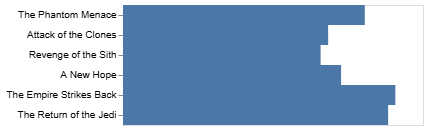

In [14]:
# display it
seenPerMovieVis

In [15]:
def augmentPercentVis(base):
    # input: base (the base vis, i.e., bars as above)
    # we're going to overlay the text with the percentages, so let's make another visualization
    # that's just text labels


    text = base.mark_text(
        align='left',
        baseline='middle',
        dx=3  # Nudges text to right so it doesn't appear on top of the bar
    ).encode(
        # we'll use the percentage as the text
        text=alt.Text('Percentage:Q',format='.0%')
    )

    # finally, we're going to combine the bars and the text and do some styling
    seen_movies = (text + base).configure_mark(
        # we don't love the blue
        color='#008fd5'
    ).configure_view(
        # we don't want a stroke around the bars
        strokeWidth=0
    ).configure_scale(
        # add some padding
        bandPaddingInner=0.2
    ).properties(
        # set the dimensions of the visualization
        width=500,
        height=180
    ).properties(
        # add a title
        title="Which 'Star Wars' Movies Have you Seen?"
    )

    return(seen_movies)

# note that we are NOT formatting this in the Five Thirty Eight Style yet... we'll leave that to you to figure out

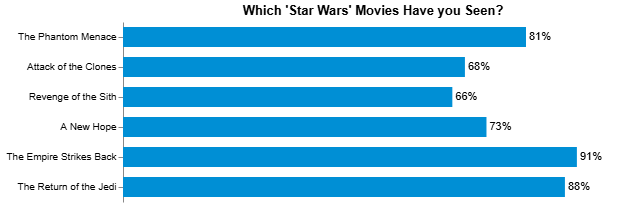

In [16]:
# let's see it
augmentPercentVis(seenPerMovieVis)

So we can see that “Star Wars: Episode V — The Empire Strikes Back” is the film seen by the most number of people, followed by “Star Wars: Episode VI — Return of the Jedi.” Appallingly, more people reported seeing “Star Wars: Episode I — The Phantom Menace” than the original “Star Wars” (renamed “Star Wars: Episode IV — A New Hope”).

So, which movie is the best? We asked the subset of 471 respondents who indicated they have seen every “Star Wars” film to rank them from best to worst. From that question, we calculated the share of respondents who rated each film as their favorite.

!["Sol1"](/voc/data/best_movie_article_resized.png)


** Homework note: Click [here](/voc/data/best_movie.png) to see a version of this plot generated in Altair.

### 2.1 What's the best 'Star Wars' movie? Recreate the above image using altair (10 Points)

Recreate the image above using Altair. Match the "538" style as best you can (hint: look at the altair lab at the start of the semester). We expect you to *at least* match the [our version](best_movie.png) of the chart that was created in Altair.

In [17]:
# Recreate this image using Altair
# match the "538 style" as best you can (hint: look at the altair lab at the start of the semester)

def genBestVis(inpf,eps, names=namesDict, names_l=namesList):
    # input: inpf, the star wars dataset
    # input: eps, the list of episodes
    # input: names - a dictionary of abbreviations to names (default: namesDict)
    # input: names_l - a list of all the movies in series order (default: namesList)
    # output: the Altair visualization as described above
    # YOUR CODE HERE
    # get viewers that have seen all movies
    seen_all = inpf.dropna(subset=['seen_' + ep for ep in eps],how='any')
    print(len(seen_all))
    
    total_all = len(seen_all)
    percentages = []

    # use example method to calculate best movie percentages and construct new dataframe with 'Names' and 'Percentages'
    for rank_ep in ['rank_' + ep for ep in eps]:
        percentage = len(seen_all.loc[inpf[rank_ep] == '1']) / total_all
        percentages.append(percentage)

    
    tuples_best = list(zip([names[ep] for ep in eps],percentages))
    df_best_movie = pd.DataFrame(tuples_best, columns = ['Name', 'Percentage'])
    #print(df_best_movie)

    # make bar chart and style as per instruction
    best_chart = alt.Chart(df_best_movie).mark_bar().encode(
        x = alt.X(
            'Percentage:Q', 
            axis=None
            ),
        y = alt.Y(
            'Name:N',
            axis=alt.Axis(tickCount=6, title='', labelFontSize=16),
            sort=names_l,
            scale=alt.Scale(paddingInner=0.25) # adjust gap between bars (from full width with no gap [bar size unspecified])
            )
    )

    text_best = best_chart.mark_text(
        align='left',
        baseline='middle',
        dx=3,
        fontSize=16
    ).encode(
        text=alt.Text('Percentage:Q',format='.0%')
    )

    top_rated = (best_chart + text_best).configure_mark(
        color='#008fd5'
    ).configure_view(
        stroke=None,
    ).configure_axisY(
        domain=False, # remove y-axis domain (line)
        ticks=False, # remove horizontal tick lines
        offset=10 # create some distance between y-axis domain (line) and base of bars/start of x-labels
    ).properties(
        width=500,
        height=220
    ).properties(
        title=alt.Title(dy=-15, # create distance between title and chart
        text="What's the Best 'Star Wars' Movie?",
        subtitle="Of 471 respondents that have seen all six films",
        anchor='start',
        fontSize=25,
        subtitleFontSize=19
        )
    ).properties(
        background = '#f0f0f0' # from https://colorbrewer2.org/#type=sequential&scheme
    )


    return top_rated

471


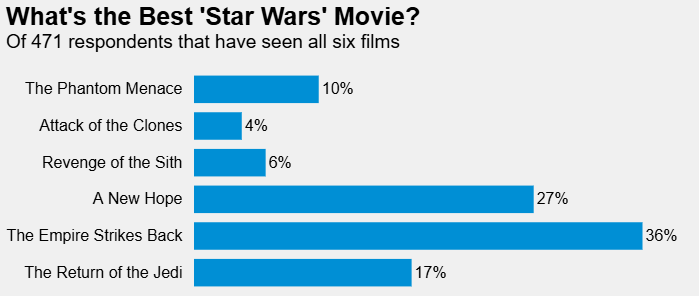

In [18]:
# test your code
genBestVis(sw,episodes)

## Make sure to *style* your visualization to match the original the best you can

We can also drill down and find out, generally, how people rate the films. Overall, fans broke into two camps: those who preferred the original three movies and those who preferred the three prequels. People who said “The Empire Strikes Back” was their favorite were also likely to rate “A New Hope” and “Return of the Jedi” higher as well. Those who rated “The Phantom Menace” as the best film were more likely to rate prequels higher.

This chart shows how often each film was rated in the top third (best or second-best), the middle third (third or fourth) or the bottom third (second-worst or worst). It’s a more nuanced take on the series:

!["Sol1"](/voc/data/how_rate_resized.png)

** Homework note: Click [here](/voc/data/people_rate.png) to see a version of this plot generated in Altair.

### 2.2 How people rate the 'Star Wars' movie? Recreate the above image using altair (10 Points)

In [19]:
# Recreate this image using altair here (10 POINTS)

def genRateVis(inpf,eps, names=namesDict, names_l=namesList):
    # input: inpf, the star wars dataset
    # input: eps, the list of episodes
    # input: names - a dictionary of abbreviations to names (default: namesDict)
    # input: names_l - a list of all the movies in series order (default: namesList)
    # output: the Altair visualization as described above
    
    # YOUR CODE HERE
    # get viewers that have seen all movies
    seen_all = inpf.dropna(subset=['seen_' + ep for ep in eps],how='any')
    print(len(seen_all))
    
    total_all = len(seen_all)
    percentages_1 = []
    percentages_2 = []
    percentages_3 = []

    for rank_ep in ['rank_' + ep for ep in eps]:
        percentage_1 = len(seen_all.loc[(seen_all[rank_ep] == '1') | (seen_all[rank_ep] == '2')]) / total_all
        percentage_2 = len(seen_all.loc[(seen_all[rank_ep] == '3') | (seen_all[rank_ep] == '4')]) / total_all
        percentage_3 = len(seen_all.loc[(seen_all[rank_ep] == '5') | (seen_all[rank_ep] == '6')]) / total_all
        percentages_1.append(percentage_1)
        percentages_2.append(percentage_2)
        percentages_3.append(percentage_3)

    
    tuples_thirds = list(zip([names[ep] for ep in eps],percentages_1,percentages_2,percentages_3))
    df_thirds = pd.DataFrame(tuples_thirds, columns = ['Name', 'Top third', 'Middle third', 'Bottom third'])
    #print(df_thirds)

    df_thirds_pivot = pd.pivot_table(df_thirds,values=['Top third','Middle third','Bottom third'],
                       columns=['Name'])

    df_thirds_long = df_thirds_pivot.copy().unstack().reset_index()
    df_thirds_long['Percentage'] = df_thirds_long[0]
    df_thirds_long['Third'] = df_thirds_long['level_1']
    df_thirds_long.drop(['level_1',0],axis=1,inplace=True)
    #print(df_thirds_long)
    
    
    # make bar chart and style as per instruction
    thirds_chart = alt.Chart(df_thirds_long).mark_bar().encode(
        x = alt.X(
            'Percentage:Q', 
            axis=None
            ),        
        y = alt.Y(
            'Name:N',
            axis=alt.Axis(tickCount=6, title='', labelFontSize=16),
            sort=names_l,
            scale=alt.Scale(paddingInner=0.25) # adjust gap between bars (from full width with no gap [bar size unspecified])
            ),
        color = alt.Color(
            'Third:N',
            scale=alt.Scale(range=['#f00', '#008fd5', '#31a354']), # from https://colorbrewer2.org/#type=sequential&scheme
            legend=None
            ),
    )

    text_thirds = thirds_chart.mark_text(
        align='left',
        baseline='middle',
        dx=3,
        fontSize=16,
        opacity=1
    ).encode(
        text=alt.Text('Percentage:Q',format='.0%'),
        color=alt.value('#000')
    )

    thirds_rated = (thirds_chart + text_thirds).properties(
        width=80,
        height=220
    )

    thirds_rated_facet = thirds_rated.facet(
        column=alt.Column(
            'Third:N',
            header=alt.Header(labelFontSize=18, labelFontStyle='bold', labelAlign='center'),
            title=None,
            sort=['Top third','Middle third','Bottom third']
            ),
        background = '#f0f0f0',
        spacing={'column':80},
        title=alt.TitleParams(
            dy=-15,
            text="How People Rate the 'Star Wars' Movies",
            subtitle=["How often each film was rated in the top, middle and bottom third",
                    "(by 471 respondents that have seen all six films)"
                    ],
            anchor='start',
            fontSize=25,
            subtitleFontSize=19
            )
    ).configure_view(
        stroke=None,
    ).configure_axisY(
        domain=False, # remove y-axis domain (line)
        ticks=False, # remove horizontal tick lines
        offset=10 # create some distance between y-axis domain (line) and base of bars/start of x-labels
    )


    return thirds_rated_facet

471


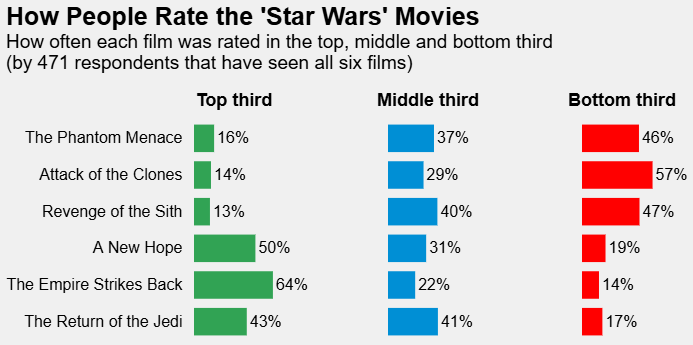

In [20]:
# let's check our solution
genRateVis(sw,episodes)

Finally, we took a boilerplate format used by political favorability polls — “Please state whether you view the following characters favorably, unfavorably, or are unfamiliar with him/her” — and asked respondents to rate characters in the series.

!["Sol1"](/voc/data/char_ranking_resized.png)


** Homework note. Here's an example solution generated in Altair:
!["Sol1"](/voc/data/people_rate_s.png)

Be careful here in what you're dividing by to get the totals for each character.

### 2.3 Star Wars' Characters Favorability Ratings. Recreate the above image using altair (10 Points)

In [21]:
# Recreate this image using altair here (10 POINTS)

def genFavorabilityVis(inpf):
    # input: inpf, the star wars dataset (as defined at top of file)
    # output: the Altair visualization as described above
    
    # YOUR CODE HERE
    character_sort_list=['Luke Skywalker','Han Solo','Princess Leia Organa','Obi Wan Kenobi','Yoda','R2 D2','C-3P0','Anakin Skywalker','Darth Vader','Lando Calrissian','Padme Amidala','Boba Fett','Emperor Palpatine','Jar Jar Binks']

    # get character viewers
    character_viewers = inpf.dropna(subset=character_sort_list,how='all')
    print(len(character_viewers))

    # get per character denominators
    total_character = []
    for name in character_sort_list:
        total_character.append(len(character_viewers[name].dropna()))
    print(total_character)
    
    percentages_1 = []
    percentages_2 = []
    percentages_3 = []
    percentages_4 = []
       

    for idx,name in enumerate(character_sort_list):
        percentage_1 = len(character_viewers.loc[(character_viewers[name] == 'Very favorably') | (character_viewers[name] == 'Somewhat favorably')]) / total_character[idx]
        percentage_2 = len(character_viewers.loc[character_viewers[name] == 'Neither favorably nor unfavorably (neutral)']) / total_character[idx]
        percentage_3 = len(character_viewers.loc[(character_viewers[name] == 'Very unfavorably') | (character_viewers[name] == 'Somewhat unfavorably')]) / total_character[idx]
        percentage_4 = len(character_viewers.loc[character_viewers[name] == 'Unfamiliar (N/A)']) / total_character[idx]
        percentages_1.append(percentage_1)
        percentages_2.append(percentage_2)
        percentages_3.append(percentage_3)
        percentages_4.append(percentage_4)

    
    tuples_characters = list(zip(character_sort_list,percentages_1,percentages_2,percentages_3,percentages_4))
    df_characters = pd.DataFrame(tuples_characters, columns = ['Names', 'Favorable', 'Neutral', 'Unfavorable','Unfamiliar'])
    #print(df_characters)

    df_characters_pivot = pd.pivot_table(df_characters, values=['Favorable', 'Neutral', 'Unfavorable','Unfamiliar'], columns=['Names'])

    df_characters_long = df_characters_pivot.copy().unstack().reset_index()
    df_characters_long['Percentage'] = df_characters_long[0]
    df_characters_long['Rating'] = df_characters_long['level_1']
    df_characters_long.drop(['level_1',0],axis=1,inplace=True)
    #print(df_characters_long)
    
    
    # make bar chart and style as per instruction
    characters_chart = alt.Chart(df_characters_long).mark_bar().encode(
        x = alt.X(
            'Percentage:Q', 
            axis=None
            ),        
        y = alt.Y(
            'Names:N',
            axis=alt.Axis(tickCount=14, title='', labelFontSize=16),
            sort=character_sort_list,
            scale=alt.Scale(paddingInner=0.15)
            ),
        color = alt.Color(
            'Rating:N',
            scale=alt.Scale(range=['#31a354','#008fd5','#bdbdbd','#f00']), # from https://colorbrewer2.org/#type=sequential&scheme
            legend=None
            ),
    )

    text_characters = characters_chart.mark_text(
        align='left',
        baseline='middle',
        dx=3,
        fontSize=16,
        opacity=1
    ).encode(
        text=alt.Text('Percentage:Q',format='.0%'),
        color=alt.value('#000')
    )

    characters_rated = (characters_chart + text_characters).properties(
        width=80,
        height=350
    )

    characters_rated_facet = characters_rated.facet(
        column=alt.Column(
            'Rating:N',
            header=alt.Header(labelFontSize=18, labelFontStyle='bold', labelAlign='center'),
            title=None,
            sort=['Favorable', 'Neutral', 'Unfavorable','Unfamiliar']
            ),
        background = '#f0f0f0',
        spacing={'column':70},
        title=alt.TitleParams(
            dy=-20,
            text="'Star Wars' Character Favorability Ratings",
            subtitle="by 834 respondents",                    
            anchor='start',
            fontSize=25,
            subtitleFontSize=19
            )
    ).configure_view(
        stroke=None,
    ).configure_axisY(
        domain=False, # remove y-axis domain (line)
        ticks=False, # remove horizontal tick lines
        offset=10 # create some distance between y-axis domain (line) and base of bars/start of x-labels
    )


    return characters_rated_facet
    

834
[831, 829, 831, 825, 826, 830, 827, 823, 826, 820, 814, 812, 814, 821]


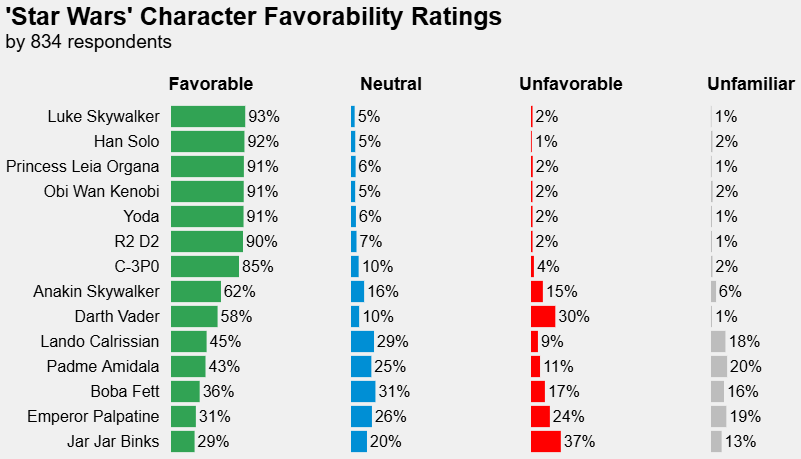

In [22]:
# let's test the solution
genFavorabilityVis(sw)

!["Sol1"](/voc/data/shot_first_article_resized.png)


** Homework note: Click [here](/voc/data/shot_first.png) to see a version of this plot generated in Altair. You may find that you don't get 834 rows (as 538 did) but the percents should still work.

### 2.4 Who shot first? Recreate the above image using altair (10 Points)

In [23]:
# Recreate this image using altair here (10 POINTS)

def genFirstShotVis(inpf):
    # input: inpf, the star wars dataset
    # output: the Altair visualization as described above
    
    # YOUR CODE HERE
    shot_all = inpf.dropna(subset='Which character shot first?')
    print(len(shot_all))
         
    df_shot = shot_all['Which character shot first?'].value_counts(normalize=True).reset_index()
    df_shot = df_shot.rename(columns={'index': 'Culprit','Which character shot first?':'Percentage' })
    #print(df_shot)
    

    # make bar chart and style as per instruction
    shot_chart = alt.Chart(df_shot).mark_bar(size=25).encode(
        x = alt.X(
            'Percentage:Q', 
            axis=None
            ),        
        y = alt.Y(
            'Culprit:N',
            axis=alt.Axis(tickCount=3, title='', labelFontSize=16, labelLimit=400, labelBaseline='middle'), # allow full label to fit by specifying pixel limit w/ labelLimit
            sort=["Han","Greedo","I don't understand this question"],
            scale=alt.Scale(paddingInner=0.2)
            )
    )
    
    text_shot = shot_chart.mark_text(
        align='left',
        baseline='middle',
        dx=3,
        fontSize=16
    ).encode(
        text=alt.Text('Percentage:Q',format='.0%')
    )

    shot_rated = (shot_chart + text_shot).configure_mark(
        color='#008fd5'
    ).configure_view(
        stroke=None,
    ).configure_axisY(
        domain=False, 
        ticks=False, 
        offset=10
    ).properties(
        width=500,
        height=220
    ).properties(
        title=alt.Title(dy=-15, # create distance between title and chart
        text="Who Shot First?",
        subtitle="According to 828 respondents",
        anchor='start',
        fontSize=25,
        subtitleFontSize=19
        )
    ).properties(
        background = '#f0f0f0' # from https://colorbrewer2.org/#type=sequential&scheme
    )


    return shot_rated

828


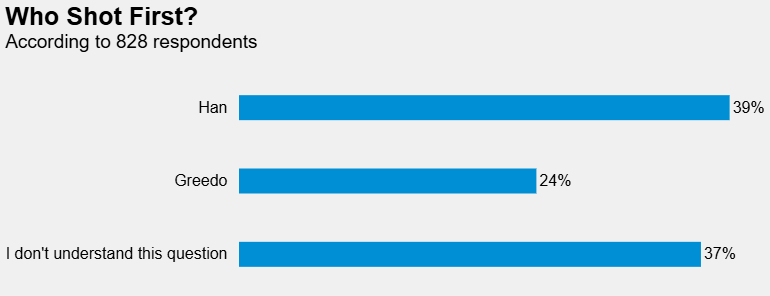

In [24]:
# test our solution
genFirstShotVis(sw)

### 2.5 Make your own (35 points total - 20 for implementation, 15 for justification)

Reading through the article, identify some aspect of the story that would benefit from an extra visualization (you can imagine extending the article if it helps). We would like for you to create two versions of this hypothetical visualization.  You should be able to convincingly argue that one visualization is better than the other.

Note: The two visualizations should use different marks and at least some of the encodings should be different. If you're struggling with coming up with two really different representations, your visualization may simply be too simple. Try to add additional columns/comparisons. 

552


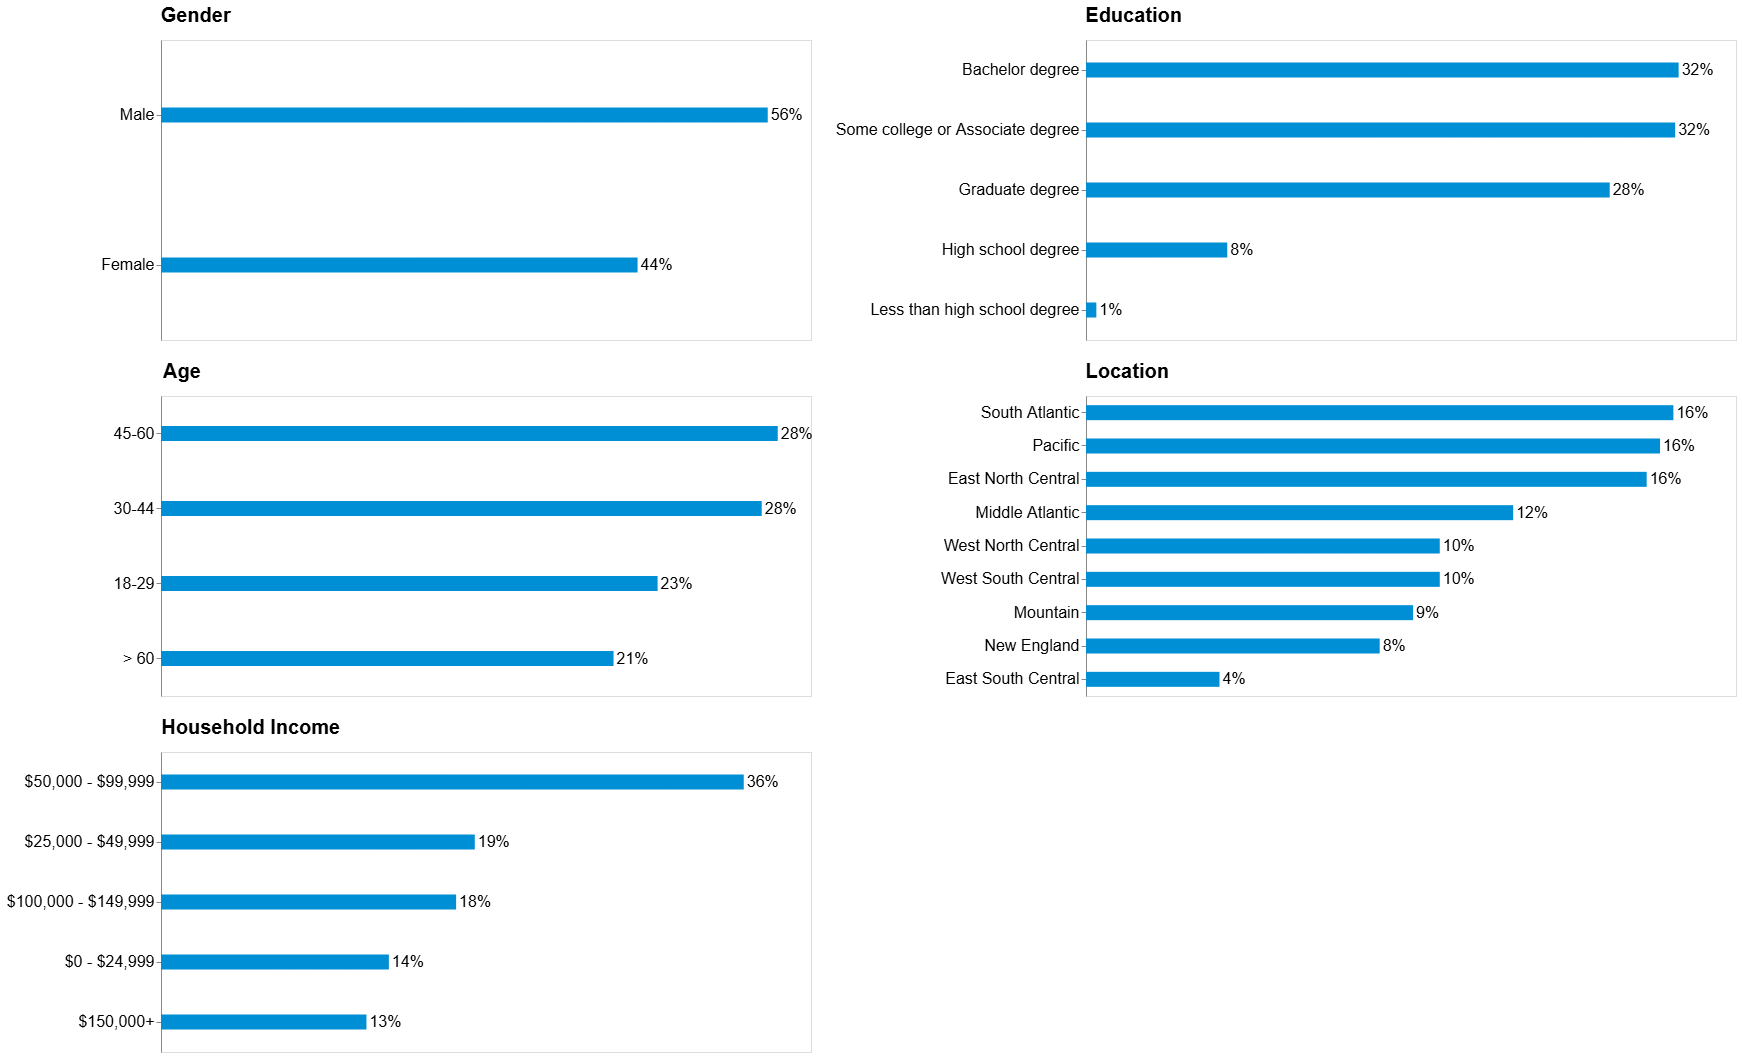

In [25]:
# YOUR CODE HERE
df_fans = sw.loc[sw['fan'] == 'Yes']
print(len(df_fans))

#create gender df
df_gender = df_fans['Gender'].value_counts(normalize=True).reset_index()
df_gender = df_gender.rename(columns={'index': 'gender','Gender':'Percentage' })
#print(df_gender)

#create age df
df_age = df_fans['Age'].value_counts(normalize=True).reset_index()
df_age = df_age.rename(columns={'index': 'age','Age':'Percentage' })
#print(df_age)

#create h_income df
df_h_income = df_fans['Household Income'].value_counts(normalize=True).reset_index()
df_h_income = df_h_income.rename(columns={'index': 'h_income','Household Income':'Percentage' })
#print(df_h_income)

#create education df
df_edu = df_fans['Education'].value_counts(normalize=True).reset_index()
df_edu = df_edu.rename(columns={'index': 'education','Education':'Percentage' })
#print(df_edu)

#create location df
df_loc = df_fans['Location (Census Region)'].value_counts(normalize=True).reset_index()
df_loc = df_loc.rename(columns={'index': 'location','Location (Census Region)':'Percentage' })
#print(df_loc)


# make base bar chart
def getBaseVis(indf):
    return alt.Chart(indf).mark_bar(size=15, color='#008fd5').encode(
    x = alt.X(
        'Percentage:Q',
        axis=None
        )    
    )
    
def markBaseVis(baseviz):
    return baseviz.mark_text(
        align='left',
        baseline='middle',
        dx=3,
        fontSize=16
    ).encode(
        text=alt.Text('Percentage:Q',format='.0%')
    )

def configBaseVis(baseviz, basevizmarked):
    return (baseviz + basevizmarked).properties(
        width=650,
        height=300
    )

# make gender chart
chart_gender = configBaseVis(getBaseVis(df_gender), markBaseVis(getBaseVis(df_gender))).encode(
    y = alt.Y(
            'gender:N',
            axis=alt.Axis(tickCount=3, title='', labelFontSize=16, labelLimit=400, labelBaseline='middle'),
            sort=['Male','Female'],
            scale=alt.Scale(paddingInner=0.2)
            )   
).properties(
        title=alt.Title(dy=-10, # create distance between title and chart
        text="Gender",
        anchor='start',
        fontSize=20,
        align='left',
        dx=60
        )
)

# make age chart
chart_age = configBaseVis(getBaseVis(df_age), markBaseVis(getBaseVis(df_age))).encode(
    y = alt.Y(
            'age:N',
            axis=alt.Axis(tickCount=3, title='', labelFontSize=16, labelLimit=400, labelBaseline='middle'),
            sort=['45-60','30-44','18-29','> 60'],
            scale=alt.Scale(paddingInner=0.2)
            )   
).properties(
        title=alt.Title(dy=-10, # create distance between title and chart
        text="Age",
        anchor='start',
        fontSize=20,
        align='left',
        dx=50
        )
)

# make h_income chart
chart_h_income = configBaseVis(getBaseVis(df_h_income), markBaseVis(getBaseVis(df_h_income))).encode(
    y = alt.Y(
            'h_income:N',
            axis=alt.Axis(tickCount=3, title='', labelFontSize=16, labelLimit=400, labelBaseline='middle'),
            sort=['$50,000 - $99,999','$25,000 - $49,999','$100,000 - $149,999','$0 - $24,999','$150,000+'],
            scale=alt.Scale(paddingInner=0.2)
            )   
).properties(
        title=alt.Title(dy=-10, # create distance between title and chart
        text="Household Income",
        anchor='start',
        fontSize=20,
        align='left',
        dx=155
        )
)

# make education chart
chart_edu = configBaseVis(getBaseVis(df_edu), markBaseVis(getBaseVis(df_edu))).encode(
    y = alt.Y(
            'education:N',
            axis=alt.Axis(tickCount=3, title='', labelFontSize=16, labelLimit=400, labelBaseline='middle'),
            sort=['Bachelor degree','Some college or Associate degree','Graduate degree','High school degree','Less than high school degree'],
            scale=alt.Scale(paddingInner=0.2)
            )   
).properties(
        title=alt.Title(dy=-10, # create distance between title and chart
        text="Education",
        anchor='start',
        fontSize=20,
        align='left',
        dx=250
        )
)

# make location chart
chart_loc = configBaseVis(getBaseVis(df_loc), markBaseVis(getBaseVis(df_loc))).encode(
    y = alt.Y(
            'location:N',
            axis=alt.Axis(tickCount=3, title='', labelFontSize=16, labelLimit=400, labelBaseline='middle'),
            sort=['South Atlantic','Pacific','East North Central','Middle Atlantic','West North Central','West South Central','Mountain','New England','East South Central'],
            scale=alt.Scale(paddingInner=0.2)
            )   
).properties(
        title=alt.Title(dy=-10, # create distance between title and chart
        text="Location",
        anchor='start',
        fontSize=20,
        align='left',
        dx=145
        )
)

end_chart_good = alt.hconcat(alt.vconcat(chart_gender,chart_age,chart_h_income),alt.vconcat(chart_edu,chart_loc))

end_chart_good

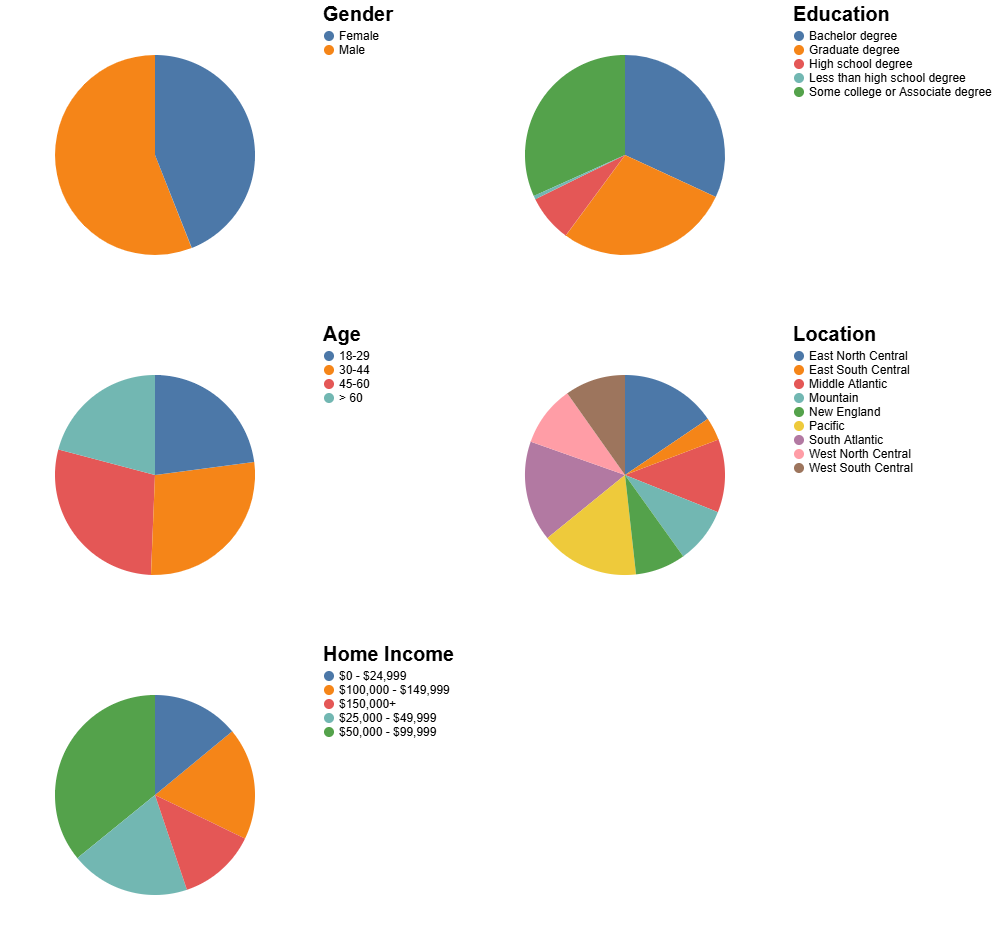

In [26]:
# YOUR CODE HERE
# make base bar chart
def getBaseVis(indf):
    return alt.Chart(indf).mark_arc(outerRadius=100).encode(
    theta=alt.Theta(
        'Percentage:Q',
        stack=True
        )
    )

   
# make gender chart
arc_gender = getBaseVis(df_gender).encode(color=alt.Color(
            'gender:N',
            legend=alt.Legend(
            title='Gender',
            titleFontSize=20,
            labelFontSize=12,
            labelLimit=200,  
            orient='right'
            )
        )
    )   

# make age chart
arc_age = getBaseVis(df_age).encode(color=alt.Color(
            'age:N',
            legend=alt.Legend(
            title='Age',
            titleFontSize=20,
            labelFontSize=12,
            labelLimit=200,  
            orient='right'
            )
        )
    )

# make h_income chart
arc_h_income = getBaseVis(df_h_income).encode(color=alt.Color(
            'h_income:N',
            legend=alt.Legend(
            title='Home Income',
            titleFontSize=20,
            labelFontSize=12,
            labelLimit=200,  
            orient='right'
            )
        )
    ) 

# make education chart
arc_edu = getBaseVis(df_edu).encode(color=alt.Color(
            'education:N',
            legend=alt.Legend(
            title='Education',
            titleFontSize=20,
            labelFontSize=12,
            labelLimit=200,  
            orient='right'
            )
        )
    )  

# make location chart
arc_loc = getBaseVis(df_loc).encode(color=alt.Color(
            'location:N',
            legend=alt.Legend(
            title='Location',
            titleFontSize=20,
            labelFontSize=12,
            labelLimit=200,  
            orient='right'
            )
        )
    ) 

arc_loc


end_chart_bad = alt.hconcat(alt.vconcat(arc_gender,arc_age,arc_h_income).resolve_scale(
                            color='independent'
                            ),
                            alt.vconcat(arc_edu,arc_loc).resolve_scale(
                            color='independent'
                            )).resolve_scale(
                            color='independent'
                            )
end_chart_bad



#### Justification
*Provide your justification here* to argue why your "better" version is actually better. Make sure to defend this based on expressiveness and effectiveness as well as perceptual arguments.

The chart grouping represents demographic data on people that identified themselves as 'Fans' of Star Wars. While both variations express the same information in its entirety and align with the spirit of the existing visualisations in the article (basic marks and annotation, simple colourchart), the bar chart concatenation above is superior in effectiveness to the pie chart concatenation. In the bar charts, we have used the encoding channels of x and y spatial position (for quantitative and categorical variables respectively) that result in a lengthwise representation of the 'size'. The human judgement of length is superior to that of angle (theta, the commencement angle of an arc in the pie chart used to encode the quantitative variable). While the accuracy of size perception of the length of the bars in the bar charts is extremely high (second only to the human perception of spatial position for quantitative representation), the size perception of angle is irregular. As Munzner highlights, it is more likely that the difference between the two angles shown in 'a' will not be perceived or quantified as accurately (both are somewhere around 25 degrees?, but no datum to guide judgement) as the difference between those shown in 'b' (we know that one of them is just over 90 degrees while the other is just under 90 degrees) :  
a) 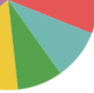                                                                    b) 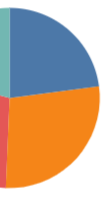

The colour encoding of the categorical variables in the pie charts also places them at an effectiveness disadvantage in comparison to the bar charts. Munzner opines that the human perception of discriminable colour for small visualisations diminishes with an increasing number of colour segments/bins. In fact, this number of segments should be limited to 6 to 12. In the pie concatenation, there is adherence to this recommendation, as the maximum number of colours in any chart does not exceed 9 and the colours used are fully saturated and easily named (also as recommended for categorical encoding). However, compared to the bar concatenation we can identify two deficiencies: 1) colour encoding of categorical variables is lower ranked than spatial position (2nd vs 1st on the APT algorithm) and 2) the pie concatenation does not avoid the red-green opponent colour axis (neither does it compensate where those colours occur by introducing luminance contrast) and therefore will not be discriminable by some readers. The bar charts avoid this issue completely by not utilising the colour channel to encode and enlisting a saturated blue as the bar colour throughout.